# Circuit-Level Trace Of Signed Memory Coefficients

This notebook reuses the projected fault-model exports produced by `ExportStimDecoderMatricesToCodeCapacityNpzs.ipynb`.

Semantics:
- `Hz`: projected DEM check matrix used by the decoder
- `Lz`: projected DEM logical-observable matrix used by the decoder
- `Hx`: **heuristic low-weight independent nulls** inside `ker([Hz; Lz])`

Important considerations:

1. These `Hx` rows are **not data-block stabilizers**.
   They are selected null fault combinations in the projected Z-sector fault model.

2. The export notebook intentionally saves **low-weight independent nulls** instead of a raw nullspace basis.
   That makes the half-support experiments and marginal traces much more meaningful.

3. The rows are still heuristic objects.
   They are useful for experiments, but they should not be oversold as a canonical generating set of the full nullspace.

4. In this trace notebook we choose one exported low-weight null row, flip exactly half its support in fault-mechanism space, compute the projected syndrome with `Hz`, and trace posterior ratios through native BP / Mem-BP iterations.

In [1]:
import json
from pathlib import Path

from IPython import get_ipython
from IPython.display import display
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import sparse

import relay_bp

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_colwidth", 200)
np.set_printoptions(edgeitems=20, linewidth=140, suppress=True)
_ip = get_ipython()
if _ip is not None:
    try:
        _ip.run_line_magic("matplotlib", "inline")
    except Exception:
        pass


In [2]:
def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "tests" / "testdata").exists():
            return candidate
    raise FileNotFoundError(f"Could not find repo root from {start}.")


repo_root = find_repo_root(Path.cwd().resolve())
export_dir = repo_root / "examples" / "notebook_data" / "stim_decoder_npz_exports"

CODE_PATHS = {
    "gross": export_dir / "gross_from_stim_Z_basis_fault_projection.npz",
    "two_gross": export_dir / "two_gross_from_stim_Z_basis_fault_projection.npz",
    "surface": export_dir / "surface13_from_stim_Z_basis_fault_projection.npz",
}

selected_code = "gross"  # change here
npz_path = CODE_PATHS[selected_code]

prior_error_rate = 0.01
max_iter = 40
alpha = 1.0
same_memory_coefficient = 0.15
random_positive_range = (0.0, 0.30)
random_signed_range = (-0.30, 0.30)
memory_application_scope = "null_support"  # options: "null_support", "all_bits"
random_coefficient_seed_offsets = [0, 1, 2]
core_seed_zero = 0
core_seed_grid = list(range(1, 11))

DECODER_SPECS = {
    "bp": {"label": "Vanilla BP", "coeff_seed_offsets": [0]},
    "mem_same": {"label": "Mem-BP / same coefficient", "coeff_seed_offsets": [0]},
    "mem_positive_random": {"label": "Mem-BP / random positive coefficients", "coeff_seed_offsets": random_coefficient_seed_offsets},
    "mem_signed_random": {"label": "Mem-BP / random signed coefficients", "coeff_seed_offsets": random_coefficient_seed_offsets},
}

In [3]:
def load_projected_fault_code(path: Path) -> dict[str, object]:
    data = np.load(path, allow_pickle=True)
    hx = np.asarray(data["Hx"], dtype=np.uint8) % 2
    hz = np.asarray(data["Hz"], dtype=np.uint8) % 2
    lz = np.asarray(data["Lz"], dtype=np.uint8) % 2
    metadata = json.loads(str(np.asarray(data["metadata_json"]).item()))
    if metadata.get("Hx_semantics") != "heuristic_low_weight_independent_nulls_in_kernel_of_[Hz;Lz]":
        raise ValueError("This notebook expects the new low-weight-null export format. Rerun ExportStimDecoderMatricesToCodeCapacityNpzs.ipynb first.")
    return {"Hx": hx, "Hz": hz, "Lz": lz, "metadata": metadata}


def choose_even_weight_null_row(hx: np.ndarray, core_seed: int) -> tuple[int, list[int]]:
    row_weights = hx.sum(axis=1)
    eligible_rows = np.flatnonzero((row_weights > 0) & ((row_weights % 2) == 0))
    if eligible_rows.size == 0:
        raise ValueError("No even-weight null row exists in Hx.")
    rng = np.random.default_rng(core_seed)
    row_idx = int(rng.choice(eligible_rows))
    support_faults = np.flatnonzero(hx[row_idx]).astype(int).tolist()
    return row_idx, support_faults


def build_half_null_fault_error(problem_seed: int, hx: np.ndarray, hz: np.ndarray, lz: np.ndarray) -> dict[str, object]:
    row_idx, support_faults = choose_even_weight_null_row(hx, problem_seed)
    if len(support_faults) % 2 != 0:
        raise ValueError("Selected Hx row is not even weight.")
    rng = np.random.default_rng(problem_seed)
    flipped_faults = sorted(rng.choice(np.asarray(support_faults, dtype=int), size=len(support_faults) // 2, replace=False).astype(int).tolist())
    error = np.zeros(hz.shape[1], dtype=np.uint8)
    error[flipped_faults] = 1
    syndrome = np.asarray((hz @ error) % 2, dtype=np.uint8).reshape(-1)
    logical_signature = np.asarray((lz @ error) % 2, dtype=np.uint8).reshape(-1)
    return {
        "core_seed": problem_seed,
        "hx_row": row_idx,
        "support_faults": support_faults,
        "flipped_faults": flipped_faults,
        "error": error,
        "syndrome": syndrome,
        "logical_signature": logical_signature,
        "row_weight": len(support_faults),
        "syndrome_weight": int(syndrome.sum()),
        "logical_weight": int(logical_signature.sum()),
    }


def get_memory_target_indices(n_bits: int, support_faults: list[int]) -> np.ndarray:
    if memory_application_scope == "null_support":
        return np.asarray(support_faults, dtype=int)
    if memory_application_scope == "all_bits":
        return np.arange(n_bits, dtype=int)
    raise ValueError(f"Unsupported memory_application_scope: {memory_application_scope}")


def build_memory_strengths(decoder_kind: str, n_bits: int, support_faults: list[int], coeff_seed: int) -> np.ndarray | None:
    if decoder_kind == "bp":
        return None
    target_indices = get_memory_target_indices(n_bits, support_faults)
    strengths = np.zeros(n_bits, dtype=np.float64)
    if decoder_kind == "mem_same":
        strengths[target_indices] = same_memory_coefficient
        return strengths
    rng = np.random.default_rng(coeff_seed)
    if decoder_kind == "mem_positive_random":
        strengths[target_indices] = rng.uniform(random_positive_range[0], random_positive_range[1], size=target_indices.size)
        return strengths
    if decoder_kind == "mem_signed_random":
        strengths[target_indices] = rng.uniform(random_signed_range[0], random_signed_range[1], size=target_indices.size)
        return strengths
    raise ValueError(f"Unsupported decoder kind: {decoder_kind}")


def make_tracer(decoder_kind: str, check_matrix, error_priors: np.ndarray):
    gamma0 = None if decoder_kind == "bp" else 0.0
    return relay_bp.MinSumBPDecoderTraceF64(check_matrix, error_priors=error_priors, max_iter=max_iter, alpha=alpha, gamma0=gamma0)


def run_single_trace(problem: dict[str, object], decoder_kind: str, coeff_seed_offset: int, check_matrix) -> dict[str, object]:
    coeff_seed = int(problem["core_seed"]) + coeff_seed_offset
    error_priors = np.full(check_matrix.shape[1], prior_error_rate, dtype=np.float64)
    tracer = make_tracer(decoder_kind, check_matrix, error_priors)
    tracer.reset()
    memory_strengths = build_memory_strengths(decoder_kind, check_matrix.shape[1], problem["support_faults"], coeff_seed)
    if memory_strengths is not None:
        tracer.set_memory_strengths(memory_strengths)
    snapshots = [tracer.snapshot(problem["syndrome"])]
    while tracer.current_iteration < max_iter and not snapshots[-1].success:
        snapshots.append(tracer.run_iteration(problem["syndrome"]))
    posterior_trace = np.vstack([np.asarray(snapshot.posterior_ratios, dtype=np.float64) for snapshot in snapshots])
    return {
        "decoder_kind": decoder_kind,
        "coeff_seed": coeff_seed,
        "coeff_seed_offset": coeff_seed_offset,
        "memory_strengths": memory_strengths,
        "snapshots": snapshots,
        "iterations": [int(snapshot.iterations) for snapshot in snapshots],
        "posterior_trace": posterior_trace,
        "final_decoding": np.asarray(snapshots[-1].decoding, dtype=np.uint8),
        "final_decoded_detectors": np.asarray(snapshots[-1].decoded_detectors, dtype=np.uint8),
        "success": bool(snapshots[-1].success),
        "final_iterations": int(snapshots[-1].iterations),
    }


def run_decoder_experiment(core_seed: int, decoder_kind: str, code_data: dict[str, object], check_matrix) -> dict[str, object]:
    problem = build_half_null_fault_error(core_seed, code_data["Hx"], code_data["Hz"], code_data["Lz"])
    runs = [run_single_trace(problem, decoder_kind, coeff_seed_offset, check_matrix) for coeff_seed_offset in DECODER_SPECS[decoder_kind]["coeff_seed_offsets"]]
    return {"problem": problem, "decoder_kind": decoder_kind, "decoder_label": DECODER_SPECS[decoder_kind]["label"], "runs": runs}


def experiment_overview_table(experiment: dict[str, object]) -> pd.DataFrame:
    problem = experiment["problem"]
    return pd.DataFrame([{
        "decoder": experiment["decoder_label"],
        "core_seed": problem["core_seed"],
        "hx_row": problem["hx_row"],
        "row_weight": problem["row_weight"],
        "support_faults": problem["support_faults"],
        "flipped_faults": problem["flipped_faults"],
        "syndrome_weight": problem["syndrome_weight"],
        "logical_weight": problem["logical_weight"],
    }])


def coefficient_table(experiment: dict[str, object]) -> pd.DataFrame:
    rows = []
    problem = experiment["problem"]
    traced_faults = problem["flipped_faults"]
    support_faults = tuple(int(bit) for bit in problem["support_faults"])
    support_fault_set = set(support_faults)
    for run in experiment["runs"]:
        strengths = run["memory_strengths"]
        final_estimated_faults = np.flatnonzero(run["final_decoding"]).astype(int).tolist()
        estimated_faults_in_support = [bit for bit in final_estimated_faults if bit in support_fault_set]
        estimated_faults_outside_support = [bit for bit in final_estimated_faults if bit not in support_fault_set]
        for bit in traced_faults:
            rows.append({
                "core_seed": problem["core_seed"],
                "decoder": experiment["decoder_label"],
                "coeff_seed": run["coeff_seed"],
                "coeff_seed_offset": run["coeff_seed_offset"],
                "fault_mechanism": bit,
                "memory_coefficient": np.nan if strengths is None else float(strengths[bit]),
                "success": run["success"],
                "iterations": run["final_iterations"],
                "support_faults": list(support_faults),
                "final_estimated_faults": final_estimated_faults,
                "estimated_faults_in_support": estimated_faults_in_support,
                "estimated_faults_outside_support": estimated_faults_outside_support,
                "n_estimated_faults": len(final_estimated_faults),
                "n_estimated_faults_outside_support": len(estimated_faults_outside_support),
            })
    return pd.DataFrame(rows)


def plot_core_seed_experiment(experiment: dict[str, object]):
    problem = experiment["problem"]
    traced_faults = problem["flipped_faults"]
    n_runs = len(experiment["runs"])
    fig, axes = plt.subplots(1, n_runs, figsize=(6.5 * n_runs, 4.5), squeeze=False)
    axes = axes.ravel()
    color_map = {bit: plt.cm.tab10(idx % 10) for idx, bit in enumerate(traced_faults)}
    line_styles = ["-", "--", "-.", ":"]
    for ax, run in zip(axes, experiment["runs"]):
        x_values = np.asarray(run["iterations"], dtype=int)
        for bit in traced_faults:
            ax.plot(x_values, run["posterior_trace"][:, bit], marker="o", linewidth=1.7, markersize=3.5, color=color_map[bit], linestyle=line_styles[run["coeff_seed_offset"] % len(line_styles)], label=f"fault {bit}")
        ax.axhline(0.0, color="black", linewidth=0.8, linestyle=":")
        ax.set_xlabel("iteration")
        ax.set_ylabel("posterior ratio")
        ax.set_title(f"coeff seed = core + {run['coeff_seed_offset']}\nsuccess = {run['success']} | iterations = {run['final_iterations']}", fontsize=10)
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="upper right")
    fig.suptitle(f"{experiment['decoder_label']} | code = {selected_code} | core seed = {problem['core_seed']}\nHx row = {problem['hx_row']} | support = {problem['support_faults']} | flipped / traced faults = {problem['flipped_faults']}", fontsize=12, y=1.03)
    fig.tight_layout()
    return fig


def plot_seed_grid(decoder_kind: str, core_seeds: list[int], code_data: dict[str, object], check_matrix):
    experiments = [run_decoder_experiment(core_seed, decoder_kind, code_data, check_matrix) for core_seed in core_seeds]
    fig, axes = plt.subplots(2, 5, figsize=(24, 10), squeeze=False)
    axes = axes.ravel()
    line_styles = ["-", "--", "-.", ":"]
    for ax, experiment in zip(axes, experiments):
        traced_faults = experiment["problem"]["flipped_faults"]
        color_map = {bit: plt.cm.tab10(idx % 10) for idx, bit in enumerate(traced_faults)}
        for run in experiment["runs"]:
            x_values = np.asarray(run["iterations"], dtype=int)
            for bit in traced_faults:
                label = f"f{bit}, +{run['coeff_seed_offset']}" if ax is axes[0] else None
                ax.plot(x_values, run["posterior_trace"][:, bit], linewidth=1.2, alpha=0.9, color=color_map[bit], linestyle=line_styles[run["coeff_seed_offset"] % len(line_styles)], label=label)
        ax.axhline(0.0, color="black", linewidth=0.6, linestyle=":")
        ax.set_title(f"core {experiment['problem']['core_seed']} | row {experiment['problem']['hx_row']}\nflip {experiment['problem']['flipped_faults']} | ok = {experiment['runs'][-1]['success']}", fontsize=9)
        ax.set_xlabel("iteration")
        ax.set_ylabel("posterior ratio")
    handles, labels = axes[0].get_legend_handles_labels()
    if handles:
        fig.legend(handles, labels, loc="upper right", fontsize=8)
    fig.suptitle(f"{DECODER_SPECS[decoder_kind]['label']} | code = {selected_code} | core seeds = {core_seeds[0]}..{core_seeds[-1]}", fontsize=13, y=1.02)
    fig.tight_layout()
    coefficient_tables = pd.concat([coefficient_table(experiment) for experiment in experiments], ignore_index=True)
    return experiments, coefficient_tables, fig


code_data = load_projected_fault_code(npz_path)
hz_check_matrix = sparse.csc_matrix(code_data["Hz"].astype(np.uint8))
metadata = code_data["metadata"]
display(pd.DataFrame([{
    "code": selected_code,
    "npz_path": str(npz_path),
    "Hx_shape": code_data["Hx"].shape,
    "Hz_shape": code_data["Hz"].shape,
    "Lz_shape": code_data["Lz"].shape,
    "hx_semantics": metadata.get("Hx_semantics", "unknown"),
    "null_search": metadata.get("null_search", {}),
    "prior_error_rate": prior_error_rate,
    "max_iter": max_iter,
    "same_memory_coefficient": same_memory_coefficient,
    "random_positive_range": random_positive_range,
    "random_signed_range": random_signed_range,
    "memory_application_scope": memory_application_scope,
}]))

,code,npz_path,Hx_shape,Hz_shape,Lz_shape,hx_semantics,null_search,prior_error_rate,max_iter,same_memory_coefficient,random_positive_range,random_signed_range,memory_application_scope
0,gross,C:\Users\User\Documents\projects-git\relay_mother_folder\relay\examples\notebook_data\stim_decoder_npz_exports\gross_from_stim_Z_basis_fault_projection.npz,"(256, 8784)","(936, 8784)","(12, 8784)",heuristic_low_weight_independent_nulls_in_kernel_of_[Hz;Lz],"{'exported_independent_rows': 256, 'exported_max_weight': 4, 'exported_median_weight': 4.0, 'exported_min_weight': 4, 'max_exported_hx_rows': 256, 'null_weight_cap': 8, 'pairwise_seed_limit': 512,...",0.01,40,0.15,"(0.0, 0.3)","(-0.3, 0.3)",null_support


## Core Seed = 0

,decoder,core_seed,hx_row,row_weight,support_faults,flipped_faults,syndrome_weight,logical_weight
0,Vanilla BP,0,217,4,"[2891, 2900, 2925, 3021]","[2925, 3021]",5,0


,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,0,Vanilla BP,0,0,2925,NaN,True,5,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
1,0,Vanilla BP,0,0,3021,NaN,True,5,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0


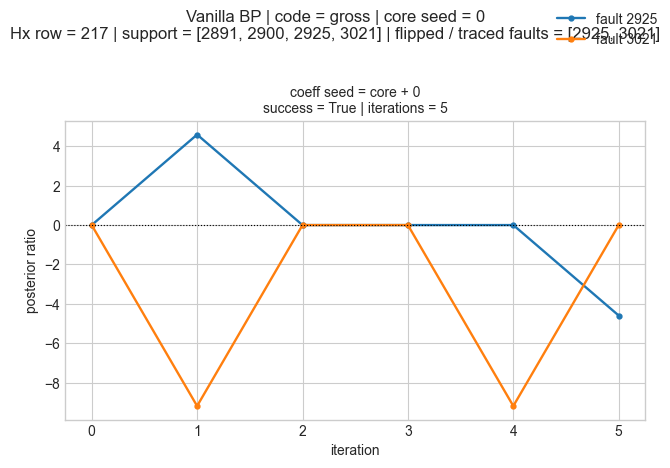

In [4]:
experiment_bp_seed0 = run_decoder_experiment(core_seed_zero, "bp", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_bp_seed0))
display(coefficient_table(experiment_bp_seed0))
fig = plot_core_seed_experiment(experiment_bp_seed0)
display(fig)
plt.close(fig)


,decoder,core_seed,hx_row,row_weight,support_faults,flipped_faults,syndrome_weight,logical_weight
0,Mem-BP / same coefficient,0,217,4,"[2891, 2900, 2925, 3021]","[2925, 3021]",5,0


,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,0,Mem-BP / same coefficient,0,0,2925,0.15,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
1,0,Mem-BP / same coefficient,0,0,3021,0.15,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0


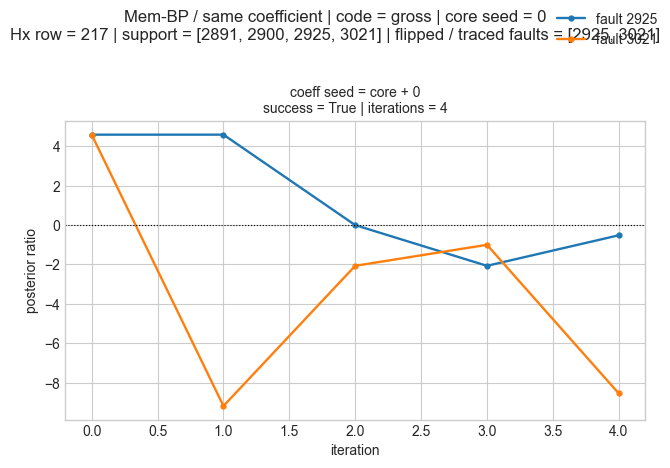

In [5]:
experiment_mem_same_seed0 = run_decoder_experiment(core_seed_zero, "mem_same", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_mem_same_seed0))
display(coefficient_table(experiment_mem_same_seed0))
fig = plot_core_seed_experiment(experiment_mem_same_seed0)
display(fig)
plt.close(fig)


,decoder,core_seed,hx_row,row_weight,support_faults,flipped_faults,syndrome_weight,logical_weight
0,Mem-BP / random positive coefficients,0,217,4,"[2891, 2900, 2925, 3021]","[2925, 3021]",5,0


,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,0,Mem-BP / random positive coefficients,0,0,2925,0.012292,True,8,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
1,0,Mem-BP / random positive coefficients,0,0,3021,0.004958,True,8,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
2,0,Mem-BP / random positive coefficients,1,1,2925,0.043248,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
3,0,Mem-BP / random positive coefficients,1,1,3021,0.284595,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
4,0,Mem-BP / random positive coefficients,2,2,2925,0.244268,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
5,0,Mem-BP / random positive coefficients,2,2,3021,0.027575,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0


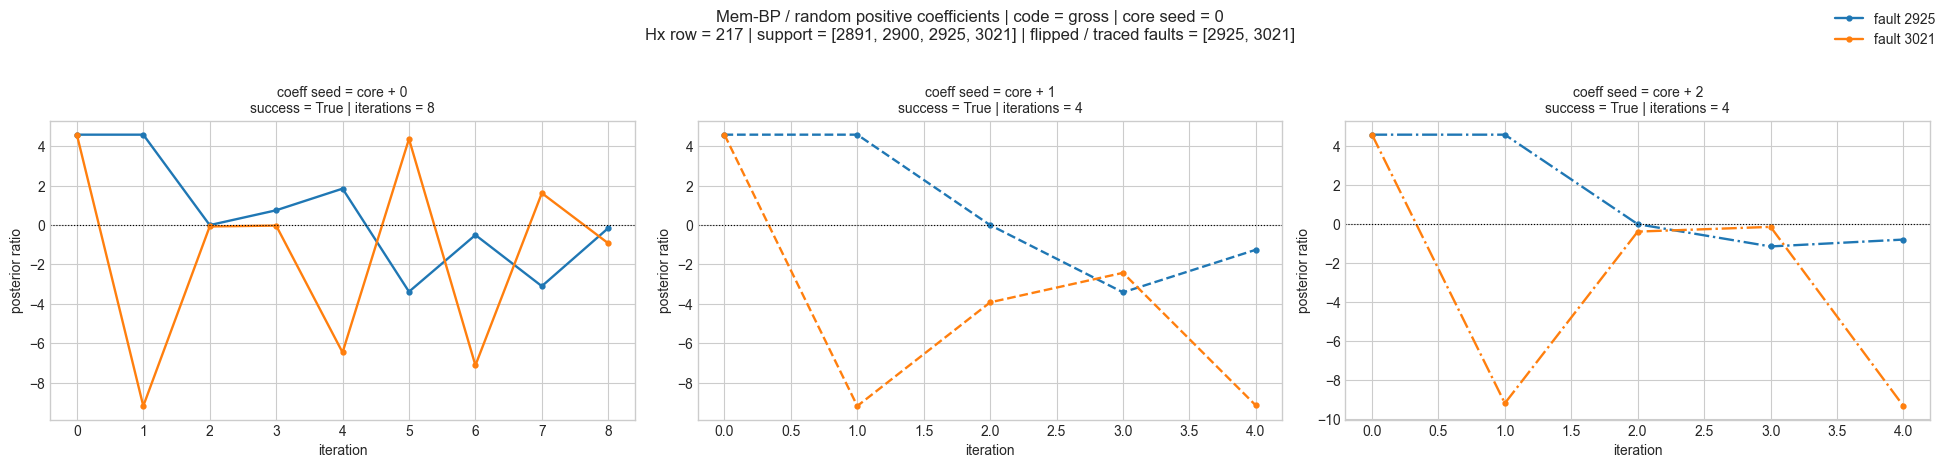

In [6]:
experiment_mem_positive_random_seed0 = run_decoder_experiment(core_seed_zero, "mem_positive_random", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_mem_positive_random_seed0))
display(coefficient_table(experiment_mem_positive_random_seed0))
fig = plot_core_seed_experiment(experiment_mem_positive_random_seed0)
display(fig)
plt.close(fig)


,decoder,core_seed,hx_row,row_weight,support_faults,flipped_faults,syndrome_weight,logical_weight
0,Mem-BP / random signed coefficients,0,217,4,"[2891, 2900, 2925, 3021]","[2925, 3021]",5,0


,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,0,Mem-BP / random signed coefficients,0,0,2925,-0.275416,True,3,"[2891, 2900, 2925, 3021]","[2891, 2900]","[2891, 2900]",[],2,0
1,0,Mem-BP / random signed coefficients,0,0,3021,-0.290083,True,3,"[2891, 2900, 2925, 3021]","[2891, 2900]","[2891, 2900]",[],2,0
2,0,Mem-BP / random signed coefficients,1,1,2925,-0.213504,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
3,0,Mem-BP / random signed coefficients,1,1,3021,0.269190,True,4,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
4,0,Mem-BP / random signed coefficients,2,2,2925,0.188535,True,8,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0
5,0,Mem-BP / random signed coefficients,2,2,3021,-0.244850,True,8,"[2891, 2900, 2925, 3021]","[2925, 3021]","[2925, 3021]",[],2,0


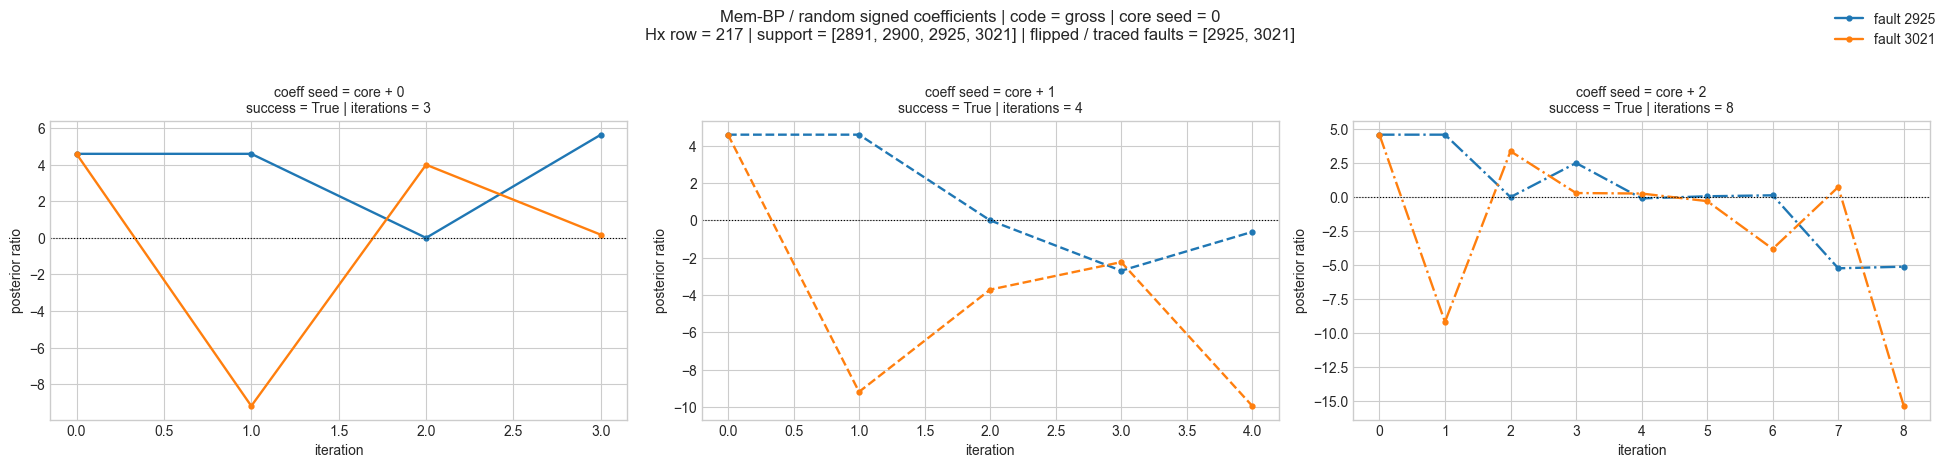

In [7]:
experiment_mem_signed_random_seed0 = run_decoder_experiment(core_seed_zero, "mem_signed_random", code_data, hz_check_matrix)
display(experiment_overview_table(experiment_mem_signed_random_seed0))
display(coefficient_table(experiment_mem_signed_random_seed0))
fig = plot_core_seed_experiment(experiment_mem_signed_random_seed0)
display(fig)
plt.close(fig)


## Core Seeds 1 To 10

,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,1,Vanilla BP,1,0,666,NaN,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
1,1,Vanilla BP,1,0,1343,NaN,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
2,2,Vanilla BP,2,0,2847,NaN,True,12,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
3,2,Vanilla BP,2,0,2855,NaN,True,12,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
4,3,Vanilla BP,3,0,2164,NaN,True,10,"[2164, 2167, 2746, 2899]",[2168],[],[2168],1,1
5,3,Vanilla BP,3,0,2746,NaN,True,10,"[2164, 2167, 2746, 2899]",[2168],[],[2168],1,1
6,4,Vanilla BP,4,0,2166,NaN,True,5,"[2131, 2140, 2166, 2343]","[2166, 2343]","[2166, 2343]",[],2,0
7,4,Vanilla BP,4,0,2343,NaN,True,5,"[2131, 2140, 2166, 2343]","[2166, 2343]","[2166, 2343]",[],2,0
8,5,Vanilla BP,5,0,2026,NaN,True,6,"[1444, 1447, 2026, 2179]","[1444, 1447]","[1444, 1447]",[],2,0
9,5,Vanilla BP,5,0,2179,NaN,True,6,"[1444, 1447, 2026, 2179]","[1444, 1447]","[1444, 1447]",[],2,0


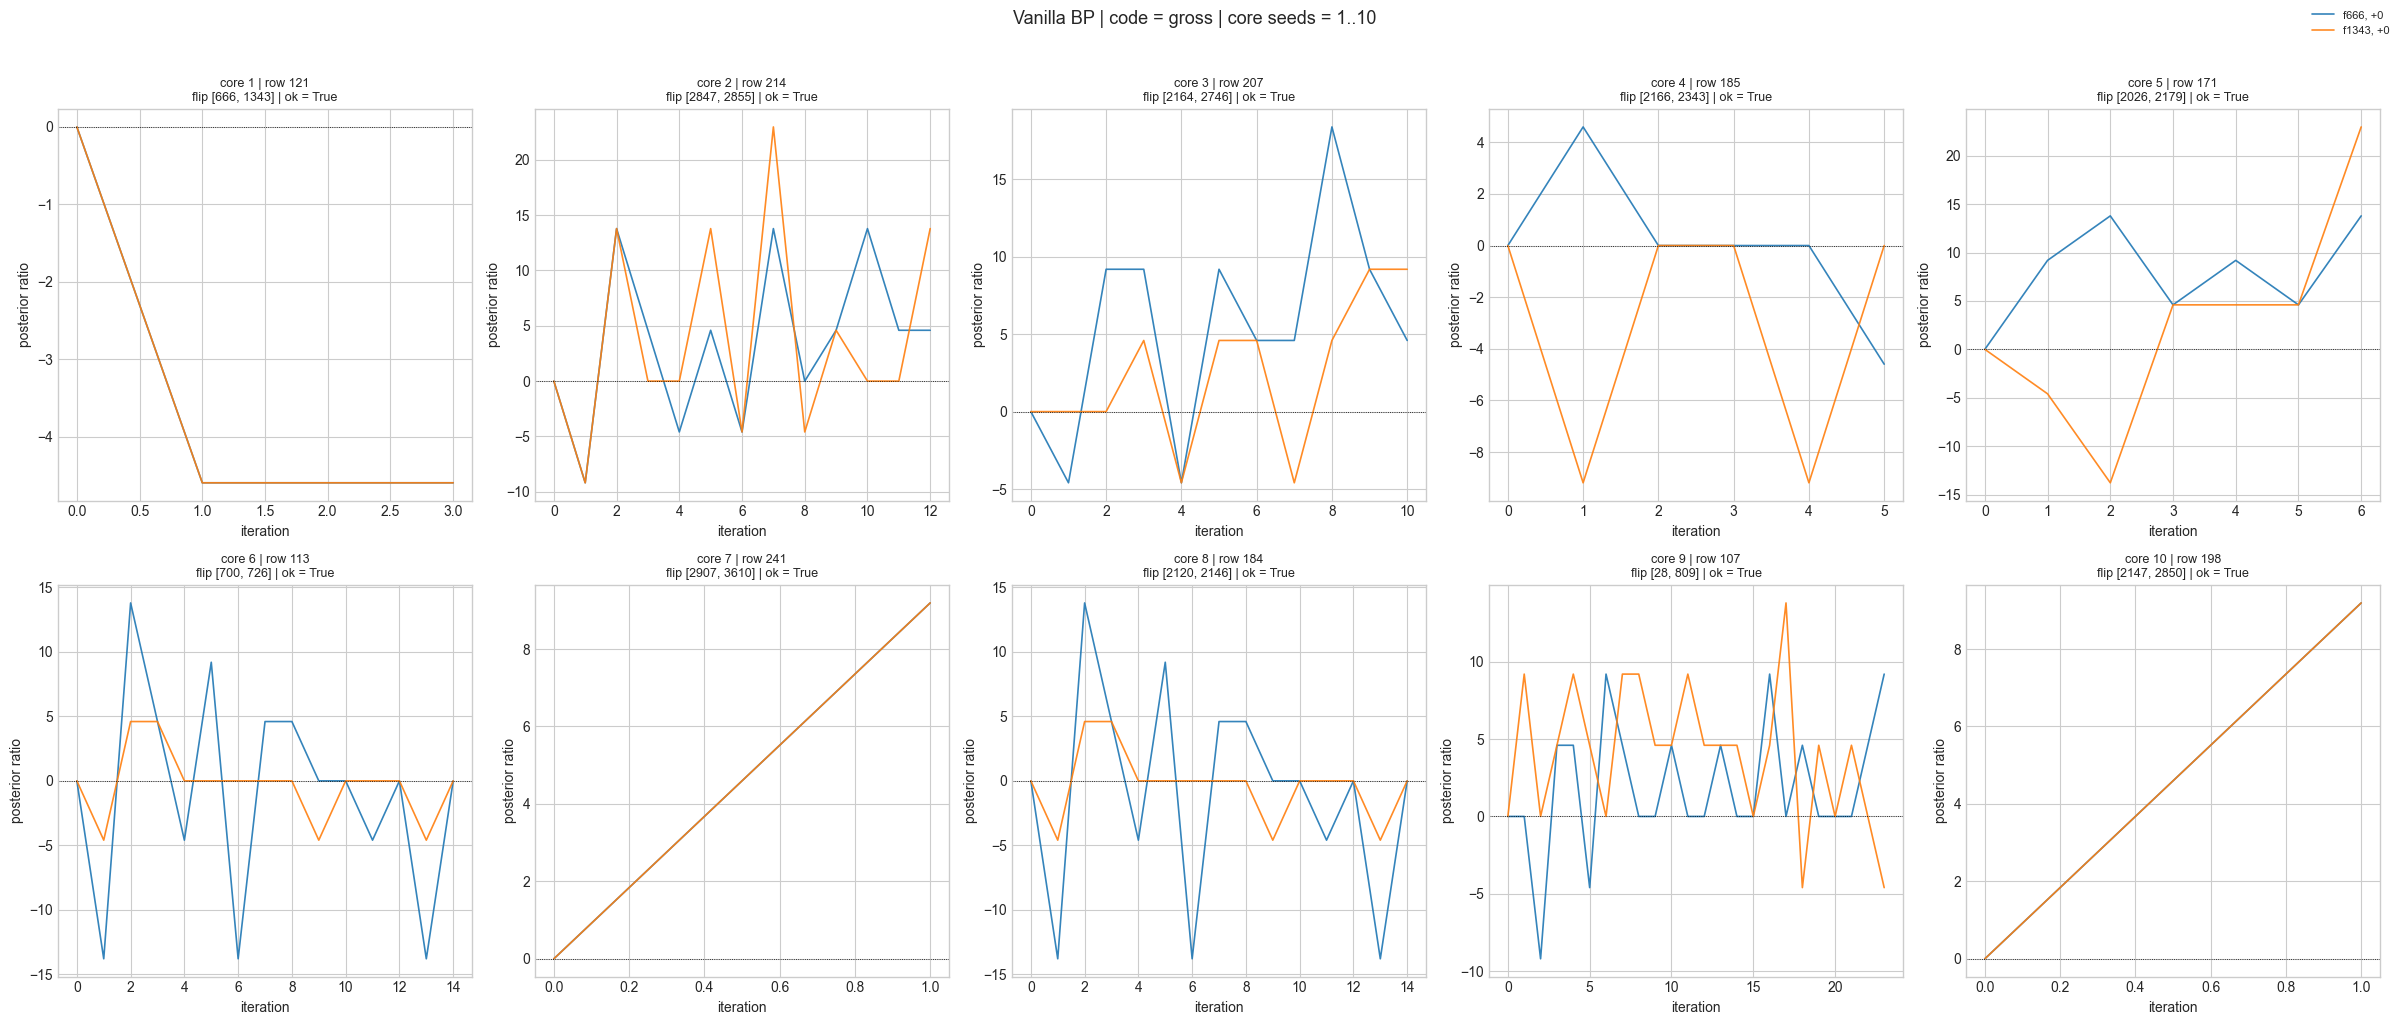

In [8]:
experiments_bp_grid, coeffs_bp_grid, fig_bp_grid = plot_seed_grid("bp", core_seed_grid, code_data, hz_check_matrix)
display(coeffs_bp_grid)
display(fig_bp_grid)
plt.close(fig_bp_grid)


,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,1,Mem-BP / same coefficient,1,0,666,0.15,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
1,1,Mem-BP / same coefficient,1,0,1343,0.15,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
2,2,Mem-BP / same coefficient,2,0,2847,0.15,True,9,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
3,2,Mem-BP / same coefficient,2,0,2855,0.15,True,9,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
4,3,Mem-BP / same coefficient,3,0,2164,0.15,True,6,"[2164, 2167, 2746, 2899]",[2168],[],[2168],1,1
5,3,Mem-BP / same coefficient,3,0,2746,0.15,True,6,"[2164, 2167, 2746, 2899]",[2168],[],[2168],1,1
6,4,Mem-BP / same coefficient,4,0,2166,0.15,True,4,"[2131, 2140, 2166, 2343]","[2166, 2343]","[2166, 2343]",[],2,0
7,4,Mem-BP / same coefficient,4,0,2343,0.15,True,4,"[2131, 2140, 2166, 2343]","[2166, 2343]","[2166, 2343]",[],2,0
8,5,Mem-BP / same coefficient,5,0,2026,0.15,True,4,"[1444, 1447, 2026, 2179]","[1444, 1447]","[1444, 1447]",[],2,0
9,5,Mem-BP / same coefficient,5,0,2179,0.15,True,4,"[1444, 1447, 2026, 2179]","[1444, 1447]","[1444, 1447]",[],2,0


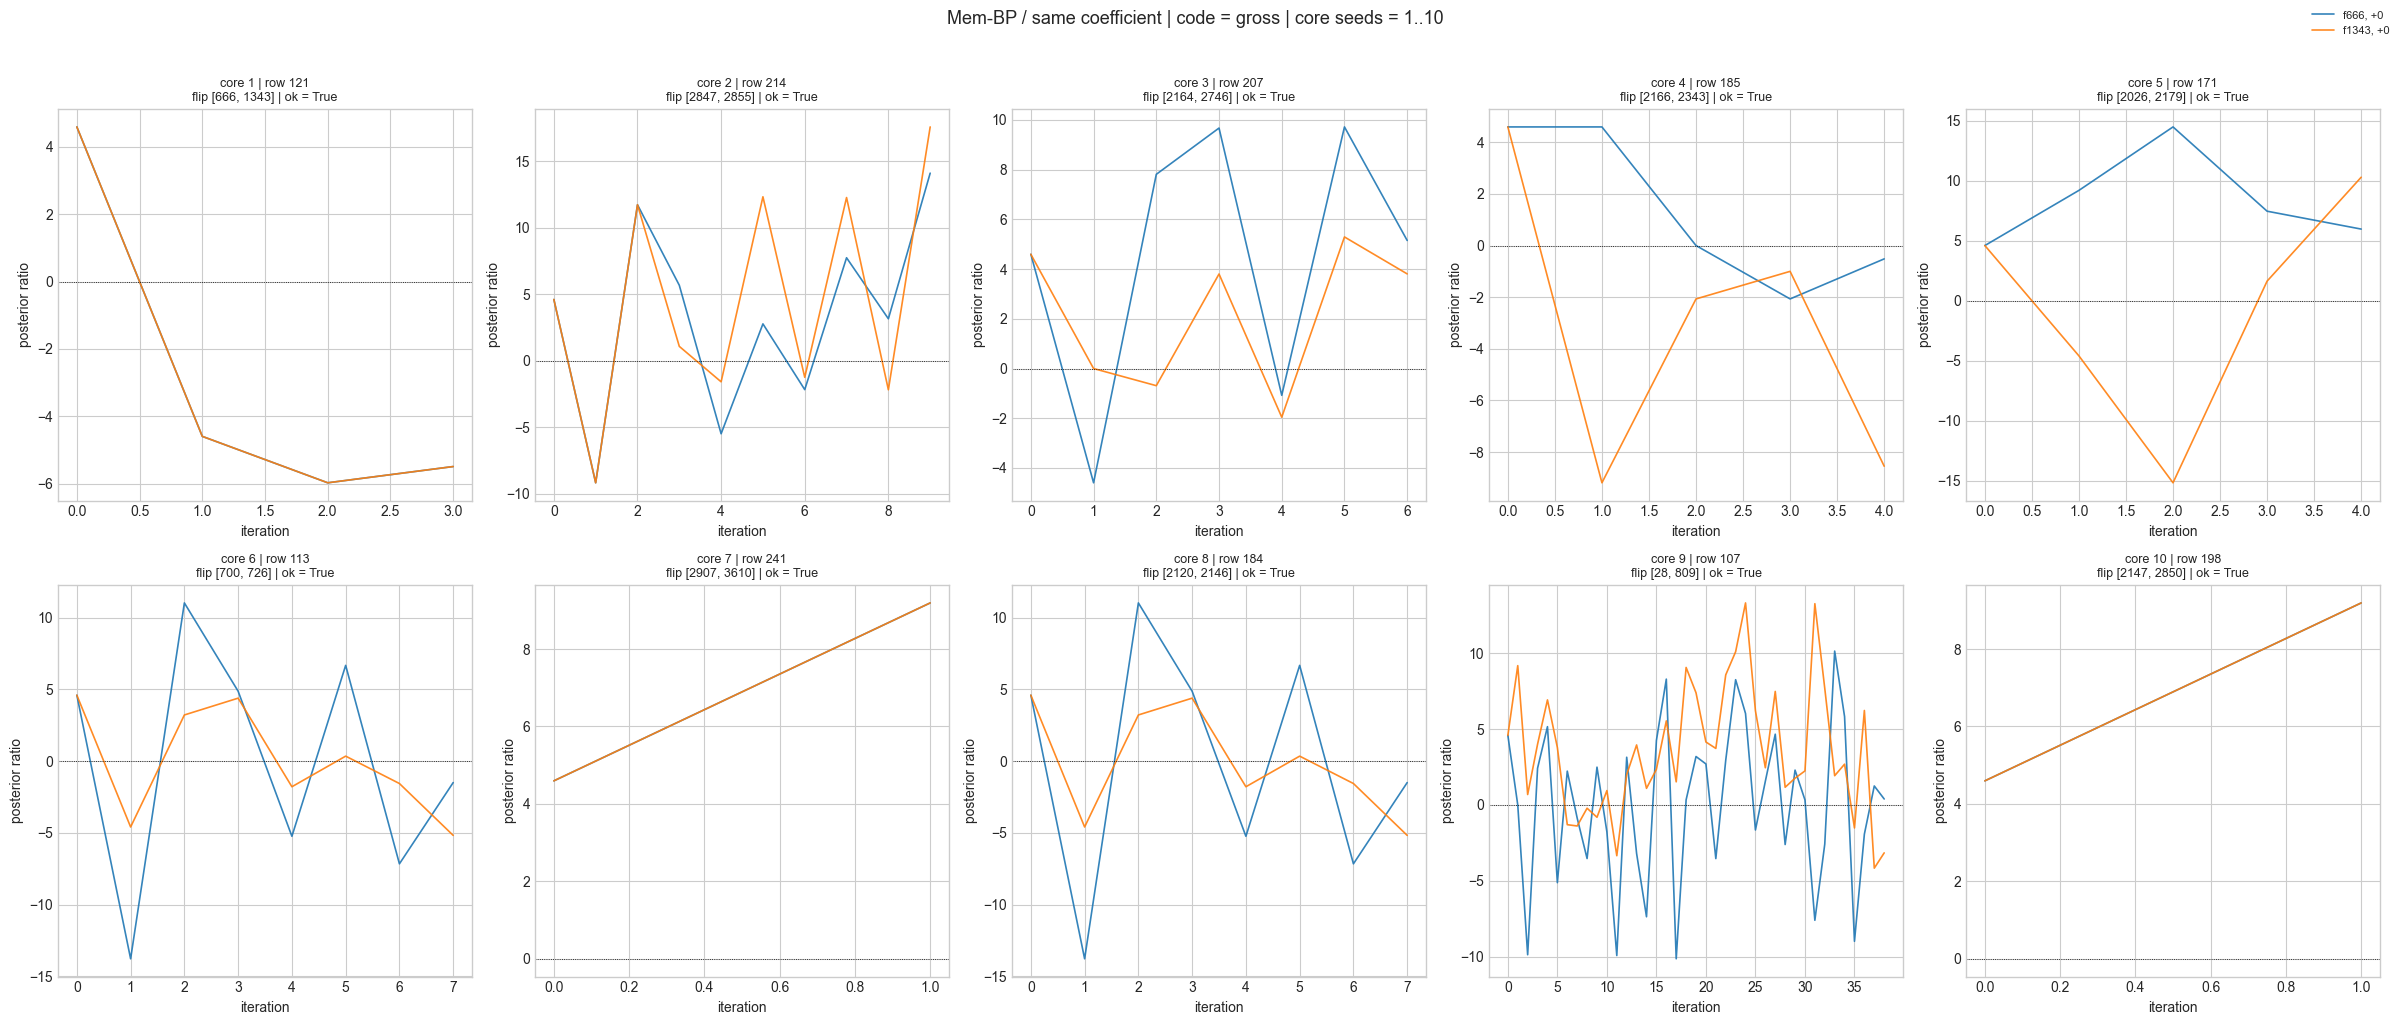

In [9]:
experiments_mem_same_grid, coeffs_mem_same_grid, fig_mem_same_grid = plot_seed_grid("mem_same", core_seed_grid, code_data, hz_check_matrix)
display(coeffs_mem_same_grid)
display(fig_mem_same_grid)
plt.close(fig_mem_same_grid)


,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,1,Mem-BP / random positive coefficients,1,0,666,0.285139,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
1,1,Mem-BP / random positive coefficients,1,0,1343,0.043248,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
2,1,Mem-BP / random positive coefficients,2,1,666,0.089547,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
3,1,Mem-BP / random positive coefficients,2,1,1343,0.244268,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
4,1,Mem-BP / random positive coefficients,3,2,666,0.071043,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
5,1,Mem-BP / random positive coefficients,3,2,1343,0.240382,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
6,2,Mem-BP / random positive coefficients,2,0,2847,0.089547,True,19,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
7,2,Mem-BP / random positive coefficients,2,0,2855,0.244268,True,19,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
8,2,Mem-BP / random positive coefficients,3,1,2847,0.071043,True,8,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
9,2,Mem-BP / random positive coefficients,3,1,2855,0.240382,True,8,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0


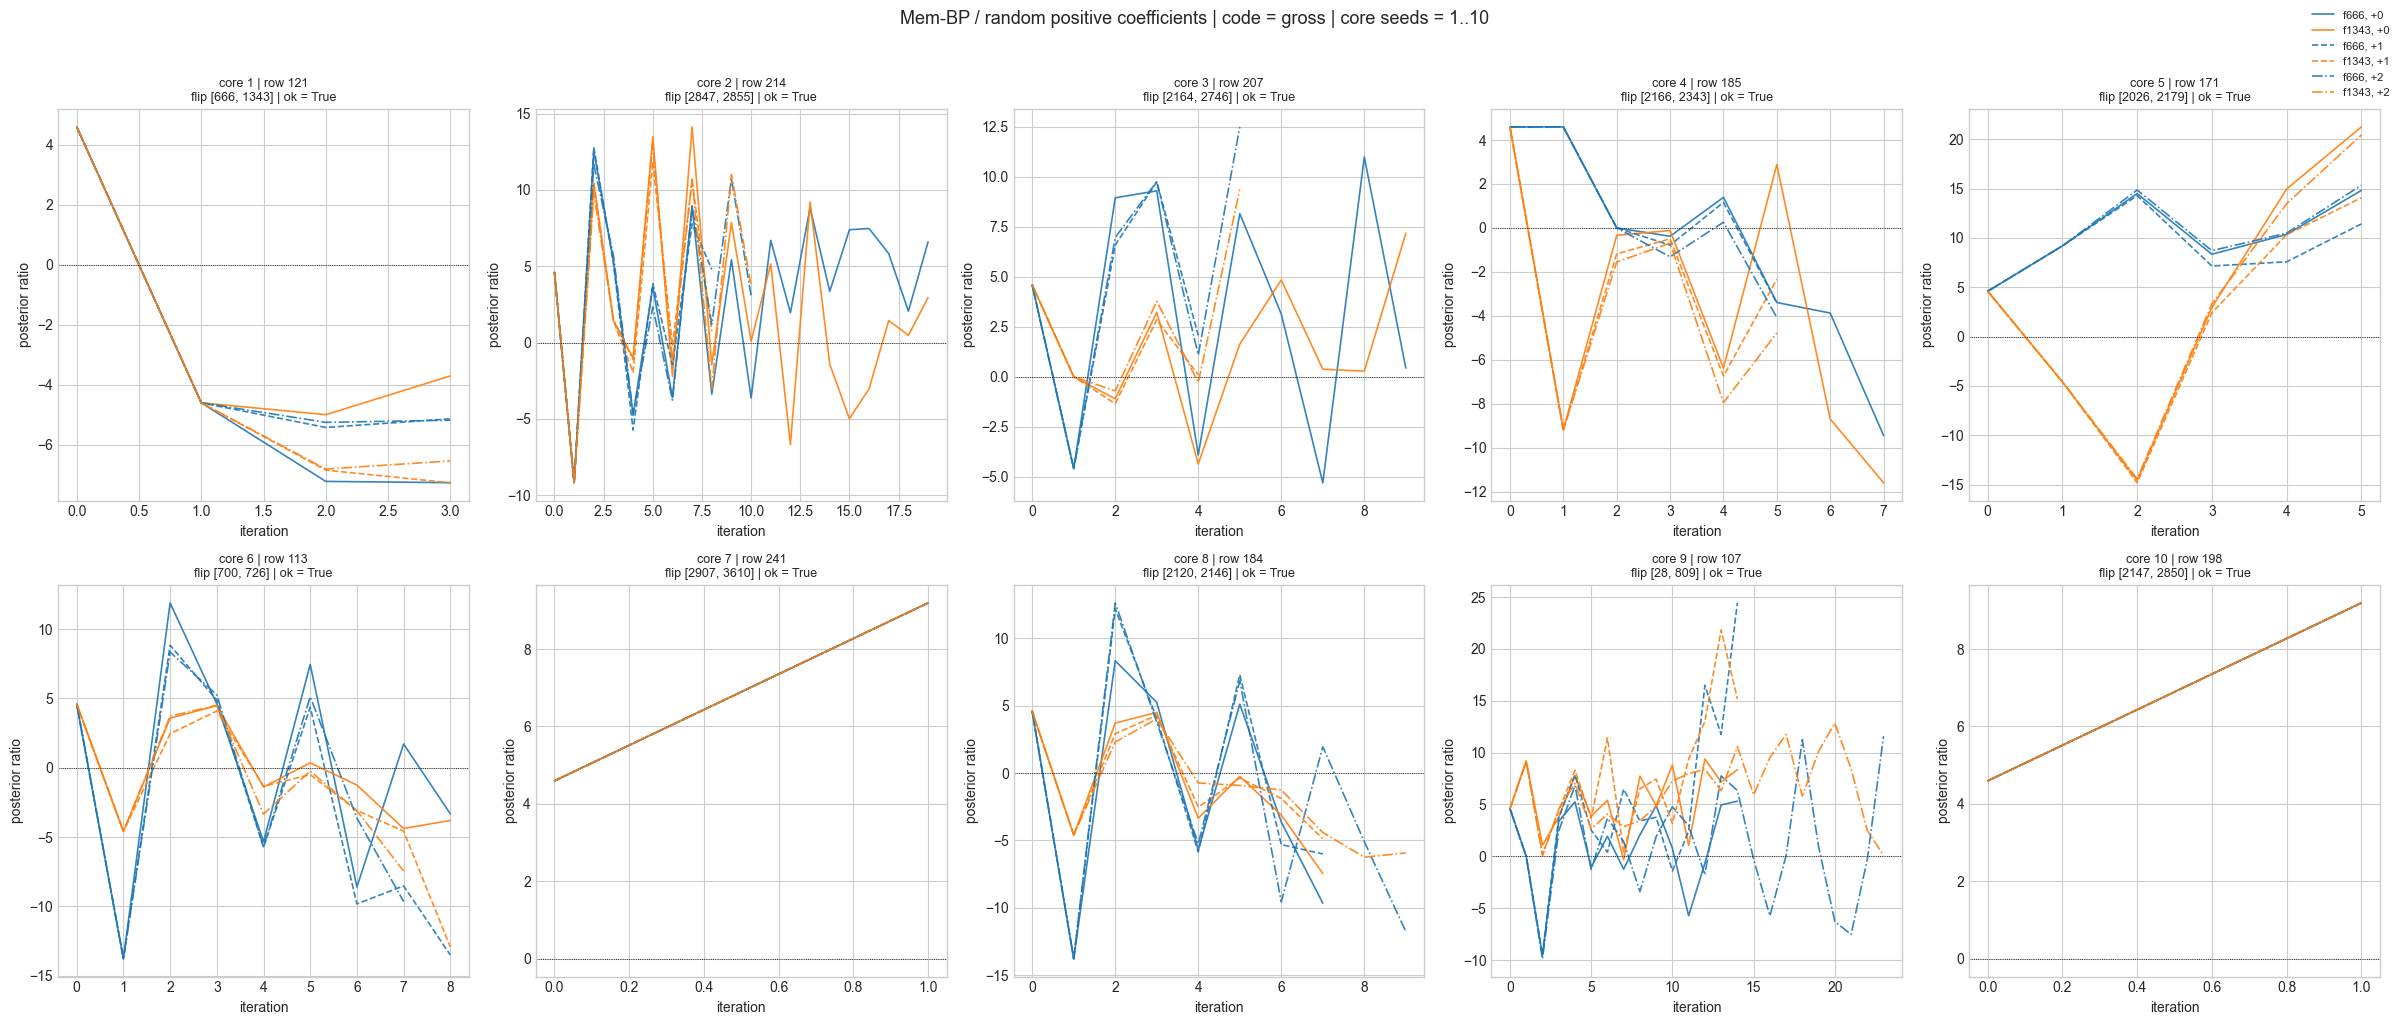

In [10]:
experiments_mem_positive_random_grid, coeffs_mem_positive_random_grid, fig_mem_positive_random_grid = plot_seed_grid("mem_positive_random", core_seed_grid, code_data, hz_check_matrix)
display(coeffs_mem_positive_random_grid)
display(fig_mem_positive_random_grid)
plt.close(fig_mem_positive_random_grid)


,core_seed,decoder,coeff_seed,coeff_seed_offset,fault_mechanism,memory_coefficient,success,iterations,support_faults,final_estimated_faults,estimated_faults_in_support,estimated_faults_outside_support,n_estimated_faults,n_estimated_faults_outside_support
0,1,Mem-BP / random signed coefficients,1,0,666,0.270278,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
1,1,Mem-BP / random signed coefficients,1,0,1343,-0.213504,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
2,1,Mem-BP / random signed coefficients,2,1,666,-0.120905,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
3,1,Mem-BP / random signed coefficients,2,1,1343,0.188535,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
4,1,Mem-BP / random signed coefficients,3,2,666,-0.157914,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
5,1,Mem-BP / random signed coefficients,3,2,1343,0.180765,True,3,"[665, 666, 1343, 1383]","[666, 1343]","[666, 1343]",[],2,0
6,2,Mem-BP / random signed coefficients,2,0,2847,-0.120905,True,4,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
7,2,Mem-BP / random signed coefficients,2,0,2855,0.188535,True,4,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
8,2,Mem-BP / random signed coefficients,3,1,2847,-0.157914,True,13,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0
9,2,Mem-BP / random signed coefficients,3,1,2855,0.180765,True,13,"[2831, 2847, 2855, 2962]","[2831, 2962]","[2831, 2962]",[],2,0


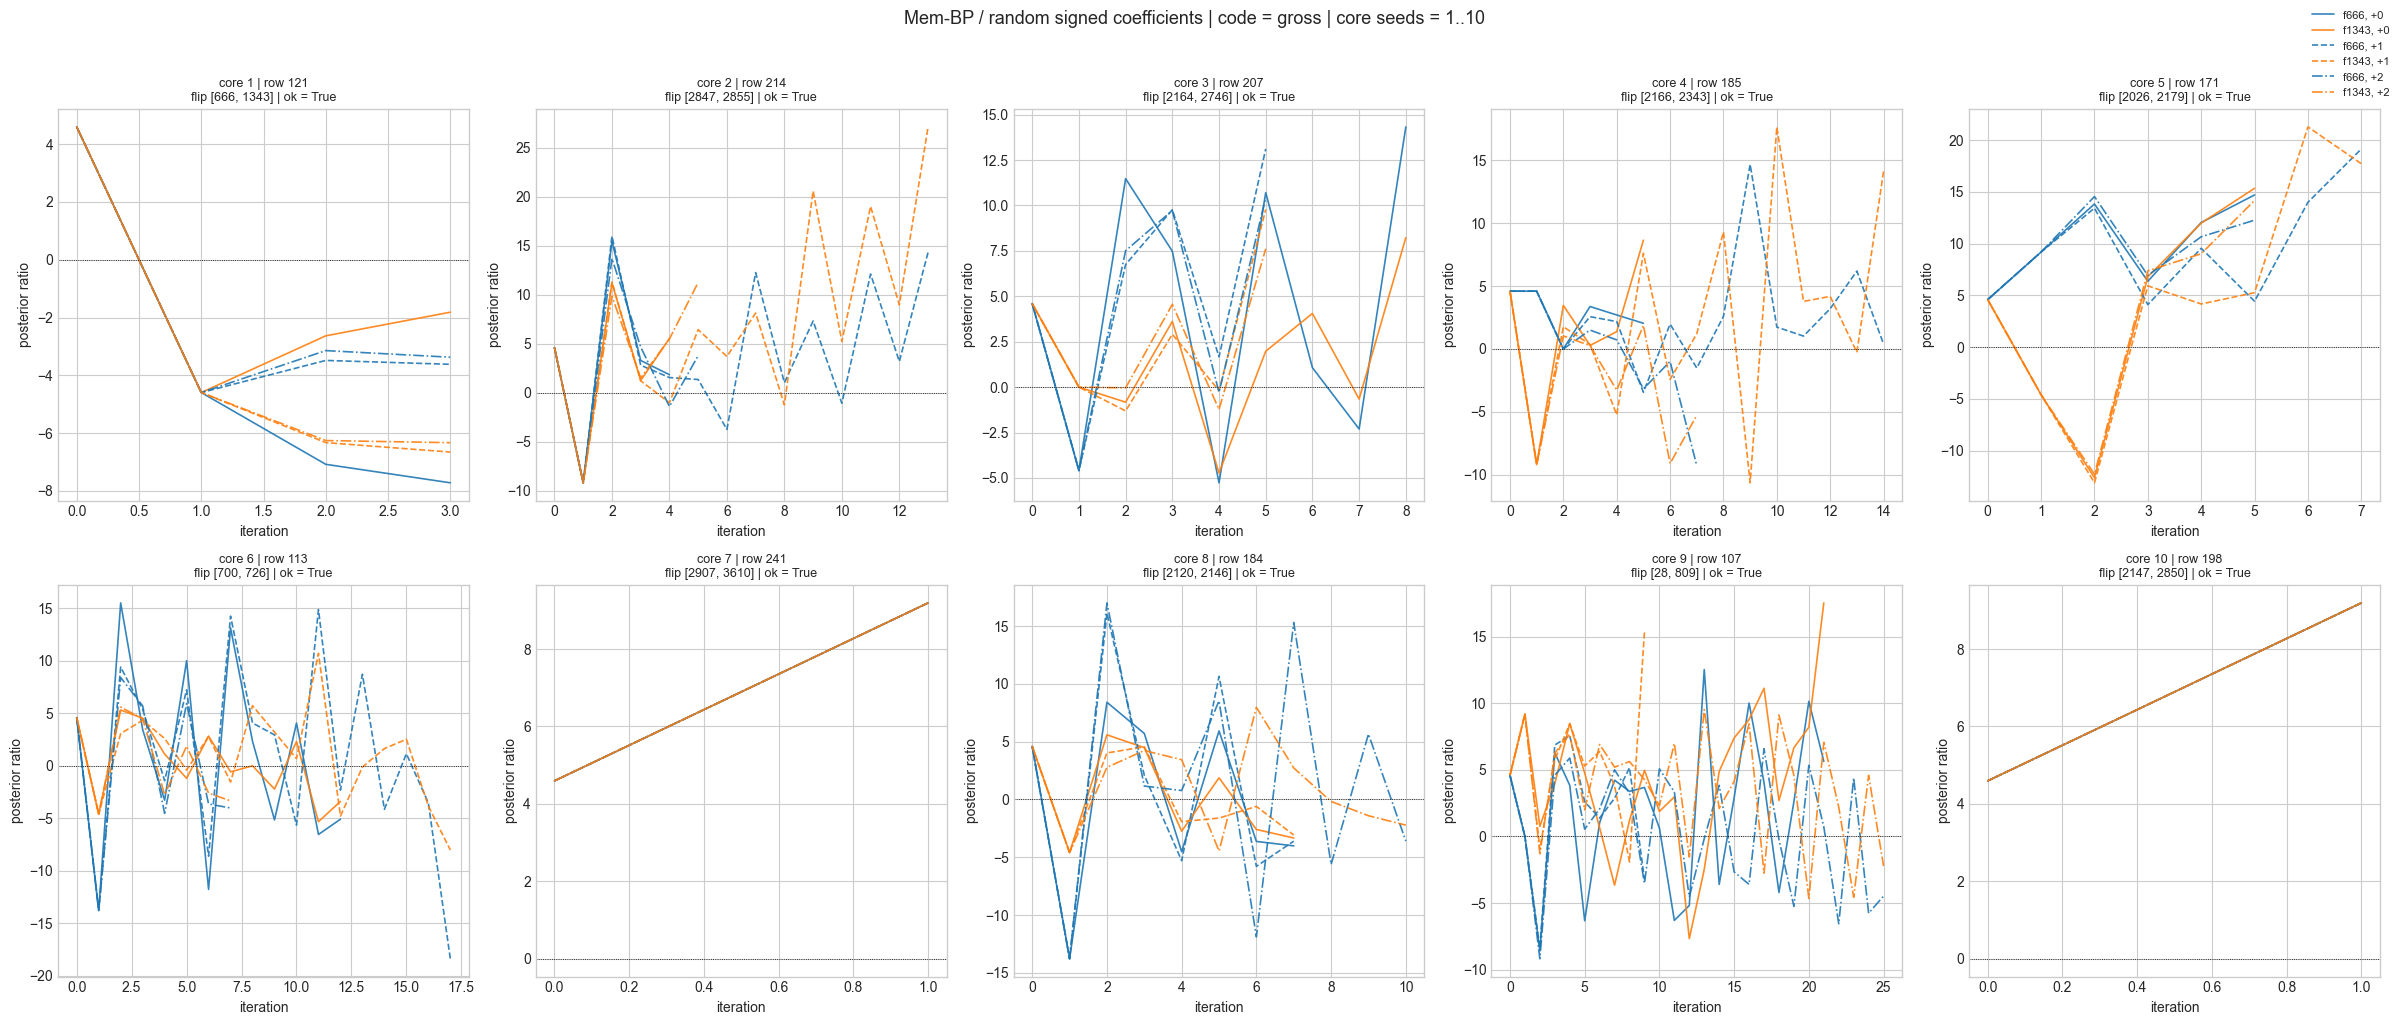

In [11]:
experiments_mem_signed_random_grid, coeffs_mem_signed_random_grid, fig_mem_signed_random_grid = plot_seed_grid("mem_signed_random", core_seed_grid, code_data, hz_check_matrix)
display(coeffs_mem_signed_random_grid)
display(fig_mem_signed_random_grid)
plt.close(fig_mem_signed_random_grid)
